In [1]:
# To - do list
# Run CellOT using their own codes and their dataset
# Apply on our cross-species dataset using cellot
# Recreate using Pytorch



In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Data loading
#cs = sc.read_h5ad("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/prediction/train_species.h5ad") 
cs = sc.read_h5ad("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot/datasets/scrna-crossspecies/hvg-top1k-train-only.h5ad") 

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [14]:
# Data inspection
# hvg stands for high variacne genes
cs

AnnData object with n_obs × n_vars = 62114 × 6619
    obs: 'condition', 'species', 'individual', 'batch', 'louvain', 'n_counts'
    var: 'gene_ids-0-0-0-0', 'gene_ids-1-0-0-0', 'gene_ids-2-0-0-0', 'gene_ids-0-1-0-0', 'gene_ids-1-1-0-0', 'gene_ids-2-1-0-0', 'gene_ids-0-0-1-0', 'gene_ids-1-0-1-0', 'gene_ids-2-0-1-0', 'gene_ids-0-1-1-0', 'gene_ids-1-1-1-0', 'gene_ids-2-1-1-0', 'gene_ids-3-1-1-0', 'gene_ids-0-0-0-1', 'gene_ids-1-0-0-1', 'gene_ids-2-0-0-1', 'gene_ids-0-1-0-1', 'gene_ids-1-1-0-1', 'gene_ids-2-1-0-1', 'gene_ids-0-0-1-1', 'gene_ids-1-0-1-1', 'gene_ids-2-0-1-1', 'gene_ids-0-1-1-1', 'gene_ids-1-1-1-1', 'gene_ids-2-1-1-1'
    uns: 'condition_colors', 'neighbors', 'species_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [8]:
# Normalization + log transformation + hvg + zscoring(standardization)
cs.X.shape
#cs.obsm["X_pca"].shape # reduced from 1000 to 50
#cs.obsm["X_umap"].shape #2 dimension 



(62114, 6619)

In [3]:
# Cell counts and metadata types
print(f"Cells: {cs.n_obs}, Genes: {cs.n_vars}")
print(f"\nConditions: {cs.obs['condition'].unique().tolist()}")
print(f"Species: {cs.obs['species'].unique().tolist()}")
print(f"Individuals: {cs.obs['individual'].unique().tolist()}")
print(f"\nbatch:\n{cs.obs['batch'].value_counts()}")
print(f"louvain:\n{cs.obs['louvain'].value_counts()}")
print(f"n_counts:\n{cs.obs['n_counts'].value_counts()}")

# Total of 62114 cells, and 6619 genes
# There are 2 different conditions, pertubed by LPS6 and unperturbed
# There are 4 different species
# 

Cells: 62114, Genes: 6619

Conditions: ['LPS6', 'unst']
Species: ['rabbit', 'pig', 'rat', 'mouse']
Individuals: ['3', '2', '1', '4']

batch:
batch
1    32897
0    29217
Name: count, dtype: int64
louvain:
louvain
0     11737
1     10540
2      8969
3      7848
7      4092
8      3436
9      3191
4      2625
5      2600
6      2536
10     1817
13     1033
11      881
12      495
14      314
Name: count, dtype: int64
n_counts:
n_counts
1495.0     23
1320.0     22
1450.0     22
1613.0     22
1341.0     22
           ..
10796.0     1
17009.0     1
10772.0     1
7352.0      1
11137.0     1
Name: count, Length: 14289, dtype: int64


In [10]:
cs.obs['cell_type'].value_counts().plot(kind='barh', figsize=(8, 5), title='Cell type counts')
plt.xlabel('Number of cells')
plt.tight_layout()

KeyError: 'cell_type'

AttributeError: module 'matplotlib' has no attribute 'xlabel'

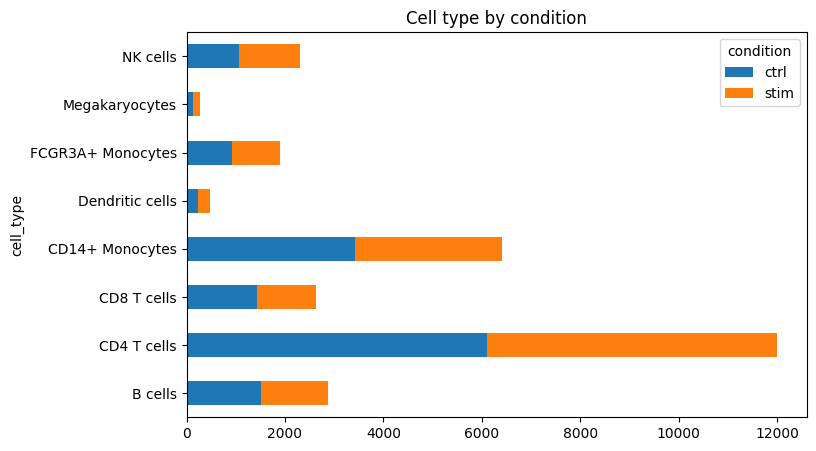

In [18]:
ct = pd.crosstab(sc_lupus.obs['cell_type'], sc_lupus.obs['condition'])
ct.plot(kind='barh', stacked=True, figsize=(8, 5), title='Cell type by condition')
plt.xlabel('Number of cells')
plt.tight_layout()

In [ ]:
# The value range indicates very likely that the value has been log transformed
# initially from 10000 to somehting like 7.3 (non-integer), probably natural log base 2.7...
# Not highly variable gene, because columns size should be restruicted to belwo 2000, we ahve 6000


# Consequence of sparse matrix, different algorithms got to be applied, optimization for sparse matrix
from scipy import sparse

X = cs.X
print(f"Type: {type(X)}")
print(f"Sparse: {sparse.issparse(X)}")
if sparse.issparse(X):
    print(f"Sparsity: {1 - X.nnz / np.prod(X.shape):.2%}")
    X_dense = X.toarray()
else:
    X_dense = X

print(f"\nValue range: [{X_dense.min():.3f}, {X_dense.max():.3f}]")
print(f"Mean: {X_dense.mean():.3f}, Std: {X_dense.std():.3f}")
print(f"Fraction of zeros: {(X_dense == 0).mean():.2%}")

Type: <class 'scipy.sparse._csr.csr_matrix'>
Sparse: True
Sparsity: 81.30%

Value range: [0.000, 7.383]
Mean: 0.179, Std: 0.478
Fraction of zeros: 81.30%


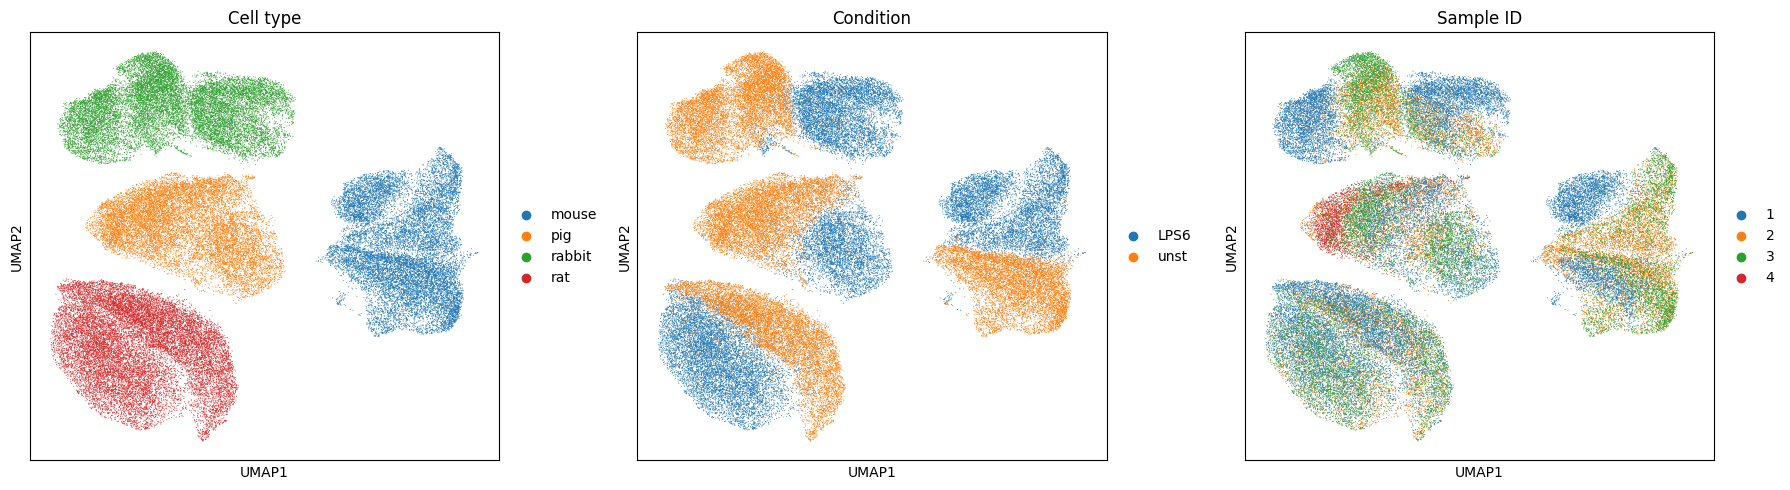

In [ ]:
# Resolution in UMAP cell type: Monocyptes
# CD4 T cells + b cells + NK cells are lympocytes
# Puncuated data on the left island not a good sign

# For the condition map
# Right
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(cs, color='species', ax=axes[0], show=False, title='Species')
sc.pl.umap(cs, color='condition', ax=axes[1], show=False, title='Condition')
sc.pl.umap(cs, color='individual', ax=axes[2], show=False, title='Individuals')
plt.tight_layout()
plt.show()

In [2]:
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2, \
                              plot_ot_transport_by_celltype

SyntaxError: invalid syntax (2957631090.py, line 1)

In [ ]:
human_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/'
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
human1_adata = human_adatas[1]
# convert_ensembl_to_gene_symbols(human1_adata, species="human", make_unique=True)

In [ ]:
mouse_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/'
mouse_adatas = top_n_organisms_from_species(mouse_dir, 2, 'mouse')
mouse1_adata = mouse_adatas[1]
# convert_ensembl_to_gene_symbols(mouse1_adata, species="mouse", make_unique=True)